In [1]:
# 1. Import libraries and load the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

file_path = "microplastic_weather_dataset_with_dates.csv"
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1627, 5)


,Date,Location_ID,Rainfall_mm,Wind_Speed_kmh,Surface_Runoff_Index
0,2025-01-01,LOC-101,0.00,33.4,0.00
1,2025-01-02,LOC-101,0.00,29.1,0.00
2,2025-01-03,LOC-101,0.00,6.8,0.00
3,2025-01-04,LOC-101,6.57,24.9,1.83
4,2025-01-05,LOC-101,7.40,30.8,1.54


In [2]:
# Check data types, missing values and summary statistics

print("Missing values:")
display(df.isna().sum())

print("\nData types:")
display(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include="all"))


Missing values:


Date                    0
Location_ID             0
Rainfall_mm             0
Wind_Speed_kmh          0
Surface_Runoff_Index    0
dtype: int64


Data types:


Date                    datetime64[ns]
Location_ID                     object
Rainfall_mm                    float64
Wind_Speed_kmh                 float64
Surface_Runoff_Index           float64
dtype: object


Summary statistics:


,Date,Location_ID,Rainfall_mm,Wind_Speed_kmh,Surface_Runoff_Index
count,1627,1627,1627.000000,1627.000000,1627.000000
unique,NaN,10,NaN,NaN,NaN
top,NaN,LOC-102,NaN,NaN,NaN
freq,NaN,169,NaN,NaN,NaN
mean,2027-03-25 00:00:00,NaN,2.146288,19.954456,1.039514
min,2025-01-01 00:00:00,NaN,0.000000,5.000000,0.000000
25%,2026-02-11 12:00:00,NaN,0.000000,12.300000,0.000000
50%,2027-03-25 00:00:00,NaN,0.000000,20.200000,0.000000
75%,2028-05-04 12:00:00,NaN,2.740000,27.100000,1.350000
max,2029-06-15 00:00:00,NaN,30.680000,35.000000,23.180000


In [3]:
# Classify rainfall conditions

def classify_weather(rainfall):
    if rainfall <= 0:
        return "Dry"
    elif rainfall < 10:
        return "Light Rain"
    elif rainfall < 30:
        return "Moderate Rain"
    else:
        return "Heavy Rain"

df["Weather_Condition"] = df["Rainfall_mm"].apply(classify_weather)

# Normalize variables using min-max scaling.
# This puts rainfall, wind and runoff onto comparable 0–1 scales.

def minmax(series):
    minimum = series.min()
    maximum = series.max()
    if maximum == minimum:
        return pd.Series(0.0, index=series.index)
    return (series - minimum) / (maximum - minimum)

df["Rainfall_Normalized"] = minmax(df["Rainfall_mm"])
df["Wind_Normalized"] = minmax(df["Wind_Speed_kmh"])
df["Runoff_Normalized"] = minmax(df["Surface_Runoff_Index"])

# Derived indicator:
# runoff receives the highest weight because it represents the transport pathway.
df["Microplastic_Transport_Risk_Index"] = (
    0.45 * df["Runoff_Normalized"] +
    0.35 * df["Rainfall_Normalized"] +
    0.20 * df["Wind_Normalized"]
) * 100

def risk_category(score):
    if score < 33:
        return "Low"
    elif score < 66:
        return "Moderate"
    else:
        return "High"

df["Transport_Risk_Category"] = df["Microplastic_Transport_Risk_Index"].apply(risk_category)

display(df[[
    "Date", "Location_ID", "Rainfall_mm", "Wind_Speed_kmh",
    "Surface_Runoff_Index", "Weather_Condition",
    "Microplastic_Transport_Risk_Index", "Transport_Risk_Category"
]].head())


,Date,Location_ID,Rainfall_mm,Wind_Speed_kmh,Surface_Runoff_Index,Weather_Condition,Microplastic_Transport_Risk_Index,Transport_Risk_Category
0,2025-01-01,LOC-101,0.00,33.4,0.00,Dry,18.933333,Low
1,2025-01-02,LOC-101,0.00,29.1,0.00,Dry,16.066667,Low
2,2025-01-03,LOC-101,0.00,6.8,0.00,Dry,1.200000,Low
3,2025-01-04,LOC-101,6.57,24.9,1.83,Light Rain,24.314409,Low
4,2025-01-05,LOC-101,7.40,30.8,1.54,Light Rain,28.631628,Low


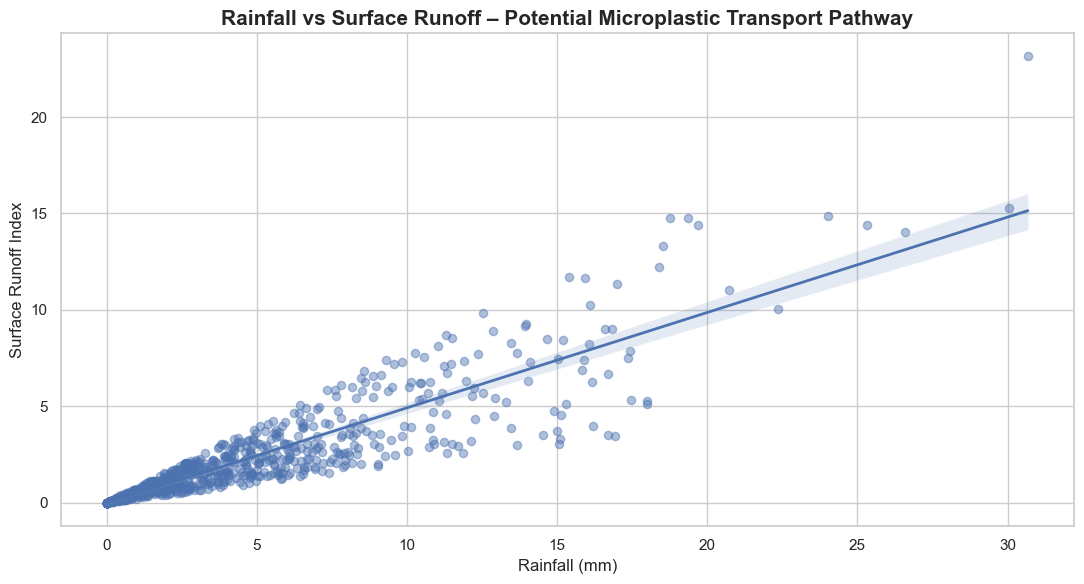

In [4]:
#rainfall vs surface 
plt.figure(figsize=(11, 6))

sns.regplot(
    data=df,
    x="Rainfall_mm",
    y="Surface_Runoff_Index",
    scatter_kws={"alpha": 0.45, "s": 35},
    line_kws={"linewidth": 2}
)

plt.title("Rainfall vs Surface Runoff – Potential Microplastic Transport Pathway",
          fontsize=15, fontweight="bold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Surface Runoff Index")
plt.tight_layout()
plt.show()

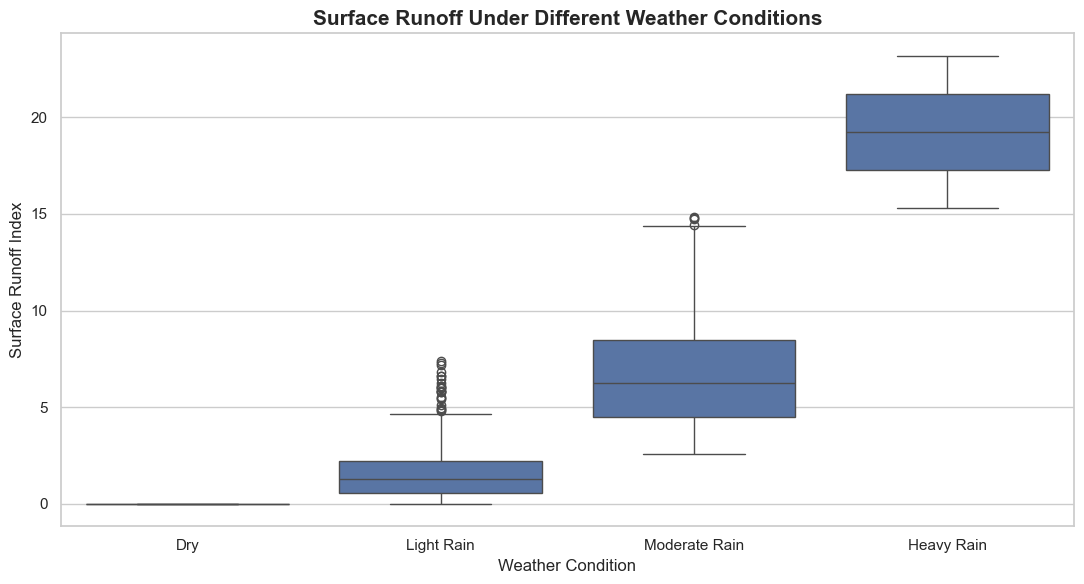

In [5]:
#surface runoff by weather
order = ["Dry", "Light Rain", "Moderate Rain", "Heavy Rain"]

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df,
    x="Weather_Condition",
    y="Surface_Runoff_Index",
    order=order
)

plt.title("Surface Runoff Under Different Weather Conditions",
          fontsize=15, fontweight="bold")
plt.xlabel("Weather Condition")
plt.ylabel("Surface Runoff Index")
plt.tight_layout()
plt.show()


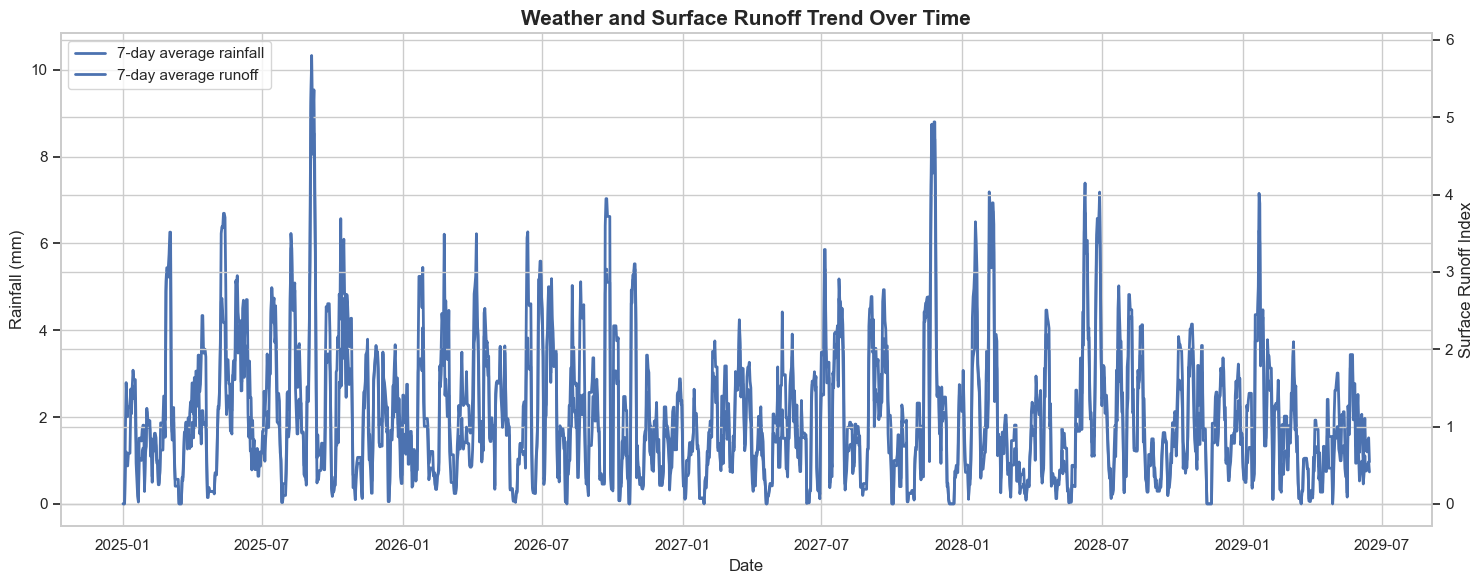

In [6]:
#weather and runoff trend overtime
# Use a rolling average to make the long-term pattern easier to see
plot_df = df.copy()
plot_df["Rainfall_7D"] = plot_df["Rainfall_mm"].rolling(7, min_periods=1).mean()
plot_df["Runoff_7D"] = plot_df["Surface_Runoff_Index"].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(
    plot_df["Date"],
    plot_df["Rainfall_7D"],
    label="7-day average rainfall",
    linewidth=2
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Rainfall (mm)")

ax2 = ax1.twinx()
ax2.plot(
    plot_df["Date"],
    plot_df["Runoff_7D"],
    label="7-day average runoff",
    linewidth=2
)
ax2.set_ylabel("Surface Runoff Index")

plt.title("Weather and Surface Runoff Trend Over Time",
          fontsize=15, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


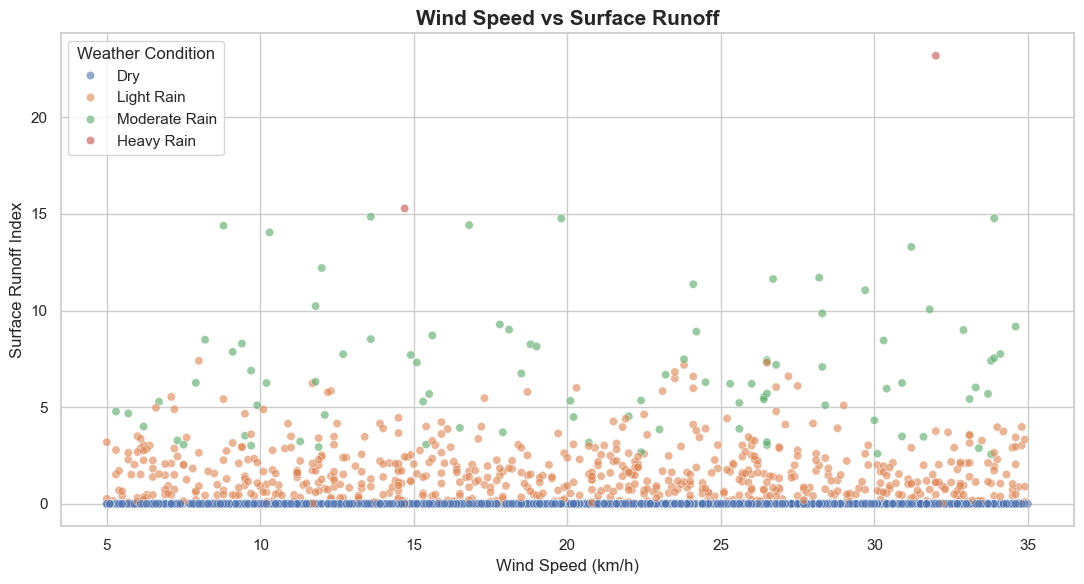

In [7]:
#windspeed vs surface runoff

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="Wind_Speed_kmh",
    y="Surface_Runoff_Index",
    hue="Weather_Condition",
    alpha=0.6
)

plt.title("Wind Speed vs Surface Runoff",
          fontsize=15, fontweight="bold")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Surface Runoff Index")
plt.legend(title="Weather Condition")
plt.tight_layout()
plt.show()


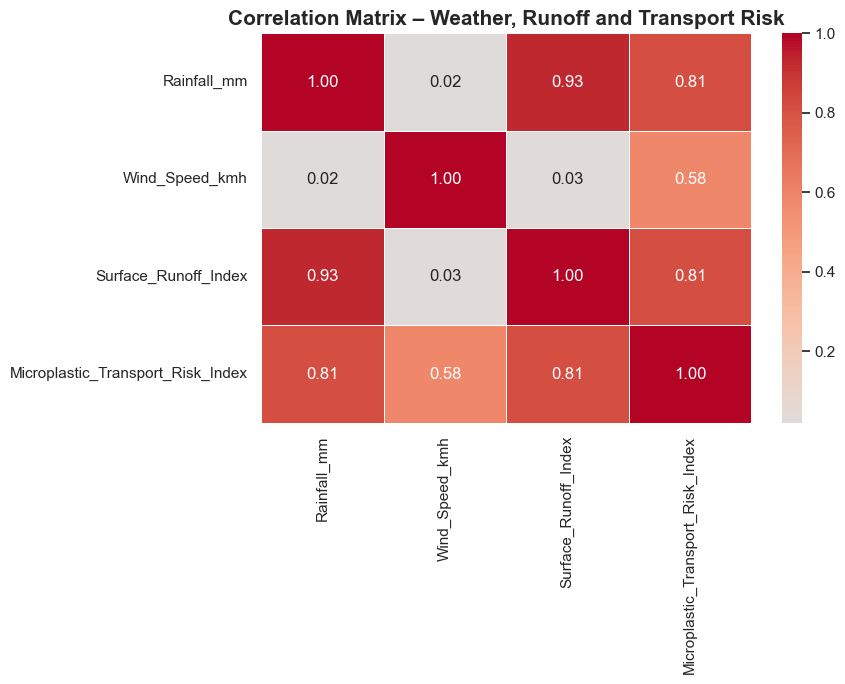

In [8]:
#correll heatmap
corr_cols = [
    "Rainfall_mm",
    "Wind_Speed_kmh",
    "Surface_Runoff_Index",
    "Microplastic_Transport_Risk_Index"
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix – Weather, Runoff and Transport Risk",
          fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


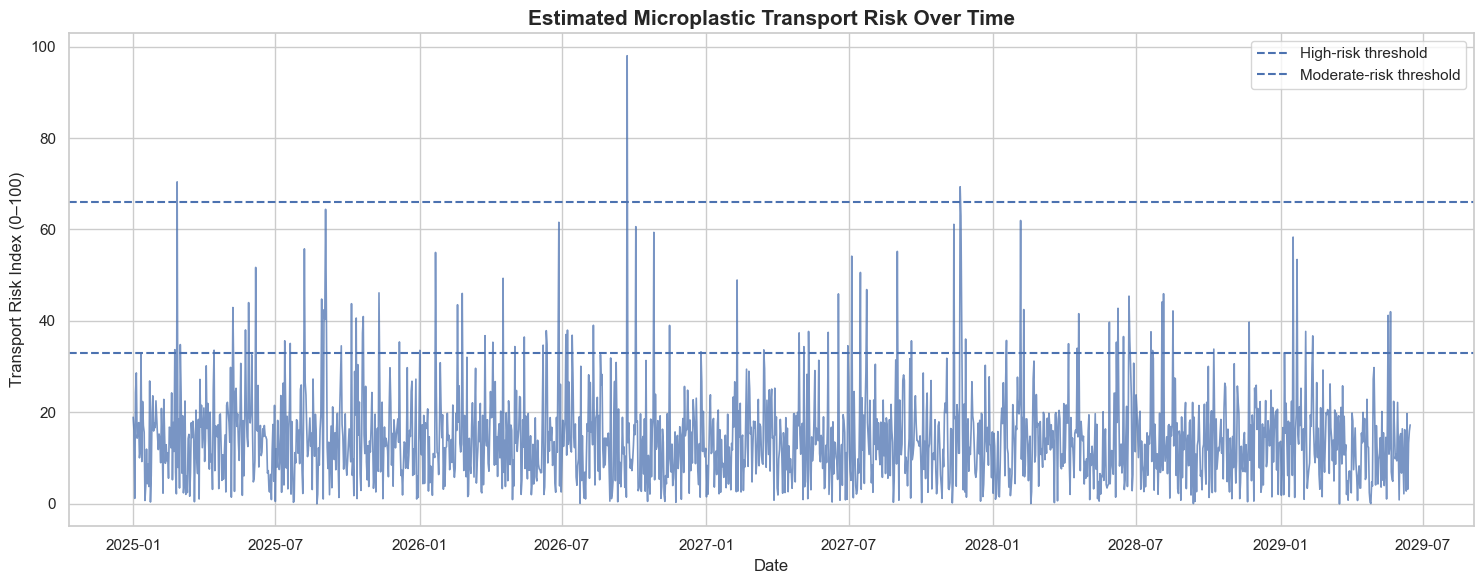

In [9]:
#microplast  transport risk overtime 
plt.figure(figsize=(15, 6))

plt.plot(
    df["Date"],
    df["Microplastic_Transport_Risk_Index"],
    linewidth=1.2,
    alpha=0.75
)

# 66 is the boundary between moderate and high risk
plt.axhline(66, linestyle="--", linewidth=1.5, label="High-risk threshold")
plt.axhline(33, linestyle="--", linewidth=1.5, label="Moderate-risk threshold")

plt.title("Estimated Microplastic Transport Risk Over Time",
          fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Transport Risk Index (0–100)")
plt.legend()
plt.tight_layout()
plt.show()


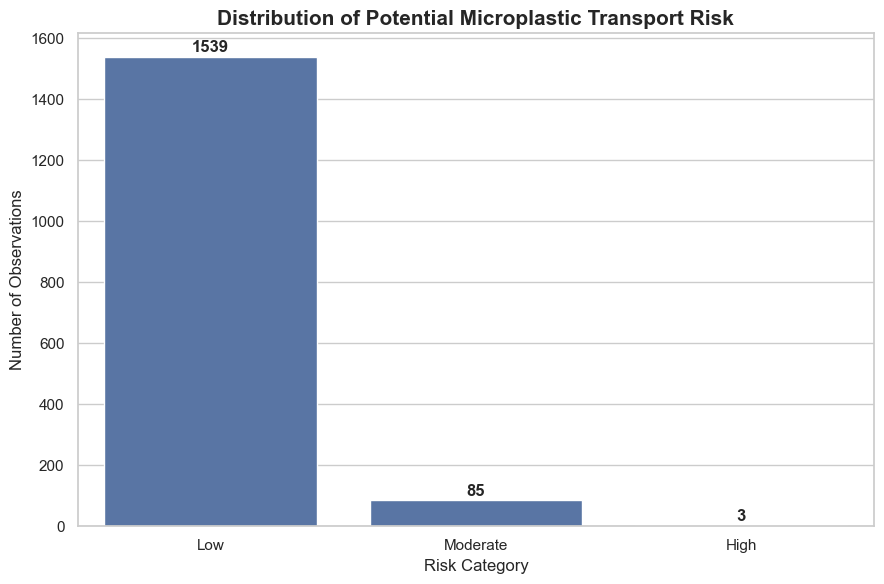

In [10]:
#risk category distribution
risk_counts = (
    df["Transport_Risk_Category"]
    .value_counts()
    .reindex(["Low", "Moderate", "High"])
    .fillna(0)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Distribution of Potential Microplastic Transport Risk",
          fontsize=15, fontweight="bold")
plt.xlabel("Risk Category")
plt.ylabel("Number of Observations")

for i, value in enumerate(risk_counts.values):
    plt.text(i, value + max(risk_counts.values) * 0.01,
             f"{int(value)}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()


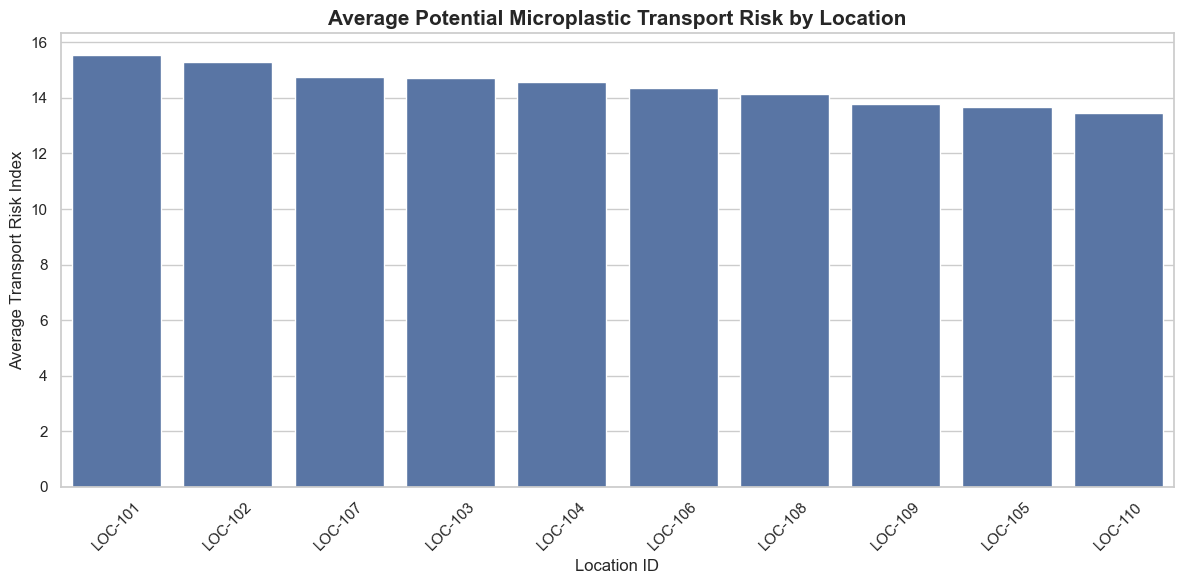

In [11]:
#loc wise  transport risk
location_risk = (
    df.groupby("Location_ID")["Microplastic_Transport_Risk_Index"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=location_risk.index.astype(str),
    y=location_risk.values
)

plt.title("Average Potential Microplastic Transport Risk by Location",
          fontsize=15, fontweight="bold")
plt.xlabel("Location ID")
plt.ylabel("Average Transport Risk Index")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
#key project statistics
# Useful numbers for your presentation/dashboard

print("========== MICROPLASTIC TRANSPORT ANALYSIS ==========")

print(f"Number of observations: {len(df):,}")
print(f"Number of locations: {df['Location_ID'].nunique()}")
print(f"Average rainfall: {df['Rainfall_mm'].mean():.2f} mm")
print(f"Average wind speed: {df['Wind_Speed_kmh'].mean():.2f} km/h")
print(f"Average runoff index: {df['Surface_Runoff_Index'].mean():.2f}")
print(f"Average transport risk index: {df['Microplastic_Transport_Risk_Index'].mean():.2f}/100")

print("\nHighest transport-risk observation:")
display(
    df.loc[
        df["Microplastic_Transport_Risk_Index"].idxmax(),
        ["Date", "Location_ID", "Rainfall_mm", "Wind_Speed_kmh",
         "Surface_Runoff_Index", "Microplastic_Transport_Risk_Index",
         "Transport_Risk_Category"]
    ].to_frame().T
)


========== MICROPLASTIC TRANSPORT ANALYSIS ==========
Number of observations: 1,627
Number of locations: 10
Average rainfall: 2.15 mm
Average wind speed: 19.95 km/h
Average runoff index: 1.04
Average transport risk index: 14.44/100

Highest transport-risk observation:


,Date,Location_ID,Rainfall_mm,Wind_Speed_kmh,Surface_Runoff_Index,Microplastic_Transport_Risk_Index,Transport_Risk_Category
629,2026-09-22 00:00:00,LOC-104,30.68,32.0,23.18,98.0,High
